In [71]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, TerminateOnNaN

In [72]:
df = pd.read_csv('train.csv', header='infer')

print(df.head(10))

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   
5      4       0       0       0       5       4       5       5       3   
6      4       0       0       0       0       0       0       0       0   
7      5       0       0       0       0       0       0       0       0   
8      4       0       0       0       0       0       0       3       2   
9      8       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1      

In [73]:
X = df.drop("label", axis=1).values
y = df["label"].values

In [74]:
X = X.astype("float32") / 255.0

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [76]:
model = Sequential([
    Input(shape=(784,)),

    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation="relu"),
    Dropout(0.2),

    Dense(10, activation="softmax")
])

optimizer = Adam(
    learning_rate=3e-4,
    clipnorm=1.0
)


In [77]:
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [78]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,506 (2.18 MB)

 Trainable params: 568,970 (2.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [79]:
callbacks = [
    TerminateOnNaN(),
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5)
]

resumen = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7632 - loss: 0.6837 - val_accuracy: 0.8277 - val_loss: 0.4719 - learning_rate: 3.0000e-04
Epoch 2/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8335 - loss: 0.4697 - val_accuracy: 0.8540 - val_loss: 0.3868 - learning_rate: 3.0000e-04
Epoch 3/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8470 - loss: 0.4246 - val_accuracy: 0.8648 - val_loss: 0.3657 - learning_rate: 3.0000e-04
Epoch 4/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8586 - loss: 0.3951 - val_accuracy: 0.8681 - val_loss: 0.3520 - learning_rate: 3.0000e-04
Epoch 5/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8634 - loss: 0.3772 - val_accuracy: 0.8729 - val_loss: 0.3484 - learning_rate: 3.0000e-04
Epoch 6/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8683 - loss: 0.3634 - val_accuracy: 0.8673 - val_loss: 0.3589 - learning_rate: 3.0000e-04
Epoch 7/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy

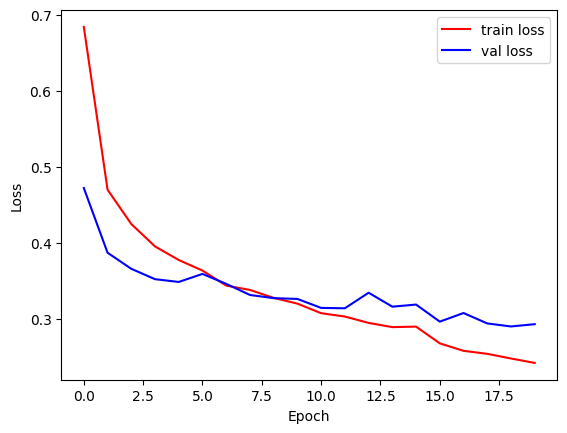

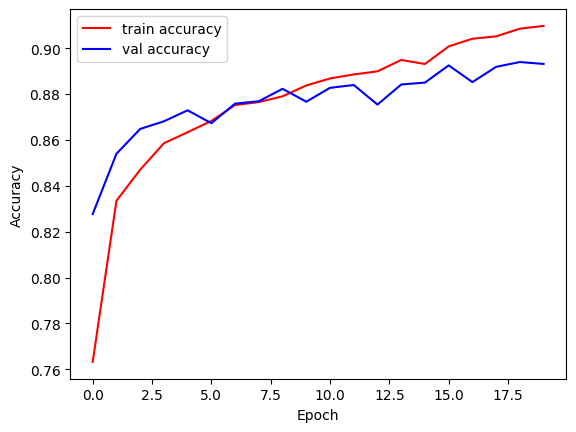

In [80]:
plt.plot(resumen.history["loss"], c='r', label="train loss")
plt.plot(resumen.history["val_loss"], c='b', label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(resumen.history["accuracy"], c='r', label="train accuracy")
plt.plot(resumen.history["val_accuracy"], c='b', label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [81]:
pred_probs = model.predict(X_test[:10])
pred_classes = np.argmax(pred_probs, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


In [82]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy :", test_acc)

Test accuracy : 0.89083331823349
